### Flux VAE test

1) loads pretrained flux.2 VAE
2) tests it on some image (encode + decode)
3) shows some intermediate steps

In [ ]:
from diffusers.models import AutoencoderKLFlux2
import torch
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms
import time

device = "cuda"

In [ ]:
vae = AutoencoderKLFlux2.from_pretrained("../../FLUX.2-klein-4B/vae", device=device).to(device)

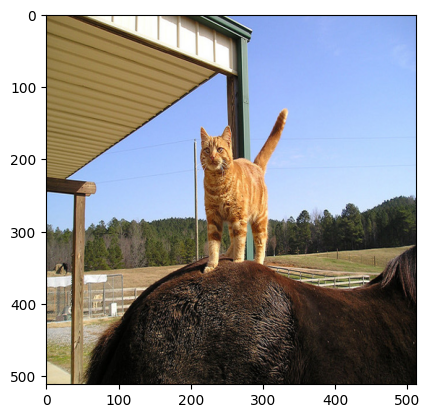

torch.Size([1, 3, 512, 512])
tensor(0., device='cuda:0') tensor(1., device='cuda:0')


In [ ]:
transform = transforms.Compose([transforms.ToTensor()])
img = Image.open("../../coco2017/train2017/000000001323.jpg").convert("RGB")
img = img.resize((512, 512))
plt.imshow(img)
plt.show()

img_tensor = transform(img)
img_tensor = img_tensor.unsqueeze(0).cuda()
print(img_tensor.shape)
print(img_tensor.min(), img_tensor.max())

### About latents_bn_mean and latents_bn_std with pathcify logic

This is likely the most non-trivial thing on Flux.2 vae usage. If we look into `diffusers.pipelines.flux2.pipeline_flux2_klein.Flux2KleinPipeline`, we can
find, that after Flux.2 generated an image it is first denormalized (shift on mean and scale by std) then unpatchified and only then passed to decoder.

This is unusual as means and std values are stored for patchified latents (128 channels), but decoder takes unpatchified 32 channel latents.

To ensure latents are normally distributed along each channel we should mimic this behaviour.

In [5]:
latents_bn_mean = vae.bn.running_mean.view(1, -1, 1, 1)
latents_bn_std = torch.sqrt(vae.bn.running_var.view(1, -1, 1, 1) + vae.config.batch_norm_eps)

def patchify_latents(latents):
    batch_size, num_channels_latents, height, width = latents.shape
    latents = latents.view(
        batch_size, num_channels_latents, height // 2, 2, width // 2, 2
    )
    latents = latents.permute(0, 1, 3, 5, 2, 4)
    latents = latents.reshape(
        batch_size, num_channels_latents * 4, height // 2, width // 2
    )
    return latents

def unpatchify_latents(latents):
    batch_size, num_channels_latents, height, width = latents.shape
    latents = latents.reshape(
        batch_size, num_channels_latents // (2 * 2), 2, 2, height, width
    )
    latents = latents.permute(0, 1, 4, 2, 5, 3)
    latents = latents.reshape(
        batch_size, num_channels_latents // (2 * 2), height * 2, width * 2
    )
    return latents


torch.Size([1, 32, 64, 64])
tensor(-7.0946, device='cuda:0') tensor(4.9879, device='cuda:0')
tensor(0.0010, device='cuda:0') tensor(1.0016, device='cuda:0')


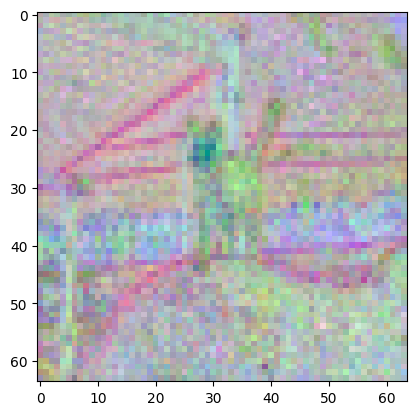

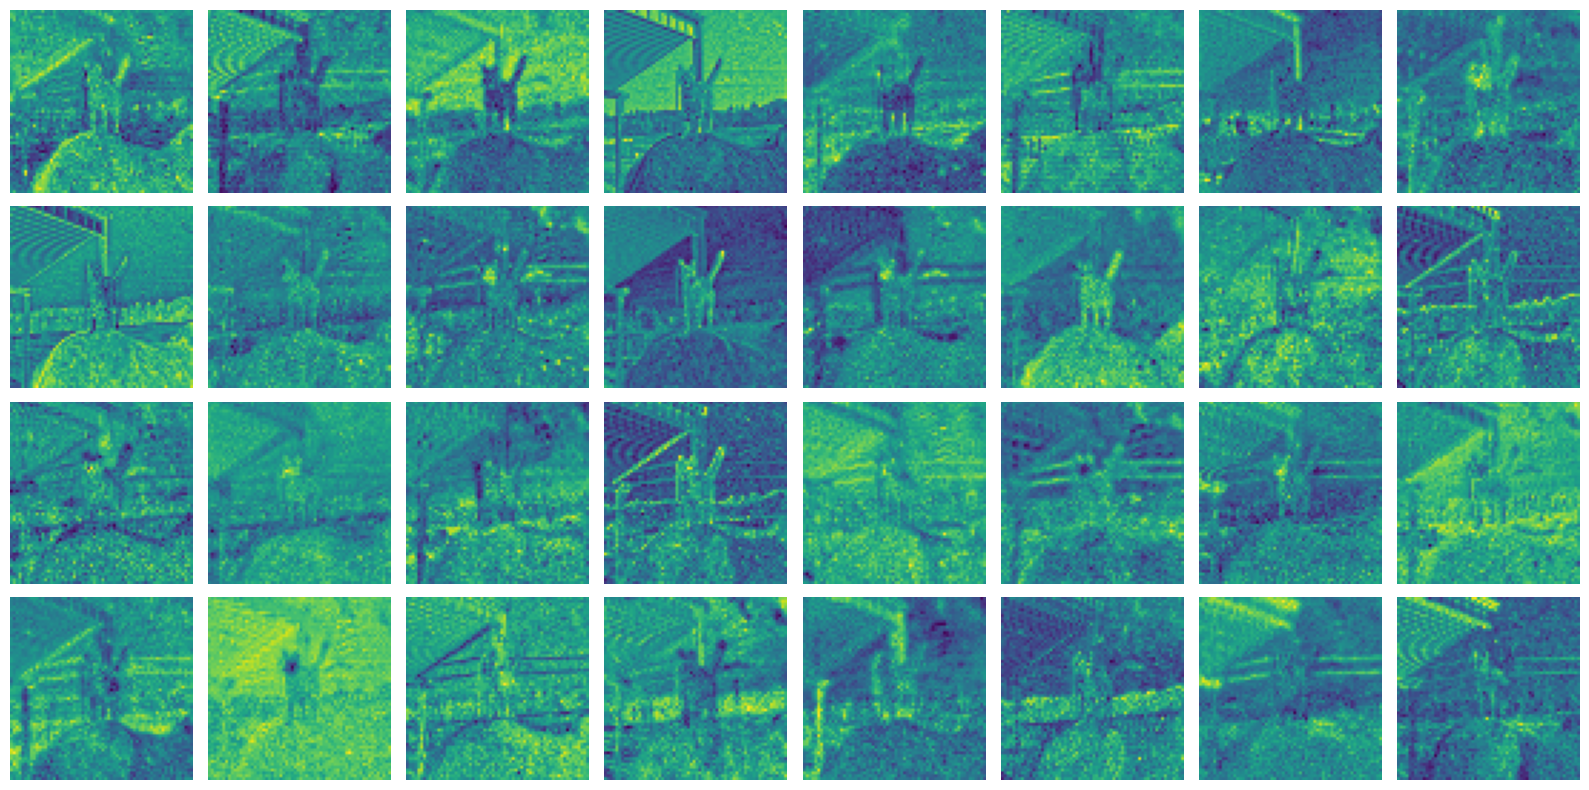

In [7]:
with torch.no_grad():
    image_norm = (img_tensor - 0.5) * 2
    latents = vae.encode(image_norm).latent_dist.mode()
    latents = patchify_latents(latents)
    latents = latents - latents_bn_mean
    latents = latents / latents_bn_std
    latents = unpatchify_latents(latents)

print(latents.shape)
print(latents.min(), latents.max())
print(latents.mean(), latents.std())

latents_np = latents.squeeze(0).permute((1, 2, 0)).cpu().numpy()[:,:,25:28] # some random 3 channels
latents_np = latents_np - latents_np.min()
latents_np = latents_np / latents_np.max()
plt.imshow(latents_np)
plt.show()

n = 32
rows = 4
cols = n // rows

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))

a = 0
for i in range(0, n):
    latents_np = latents.squeeze(0).permute((1, 2, 0)).cpu().numpy()[:,:,i]
    latents_np = latents_np - latents_np.min()
    latents_np = latents_np / latents_np.max()
    axes[a // cols][a % cols].imshow(latents_np)
    axes[a // cols][a % cols].axis("off")
    a += 1

plt.tight_layout()
plt.show()


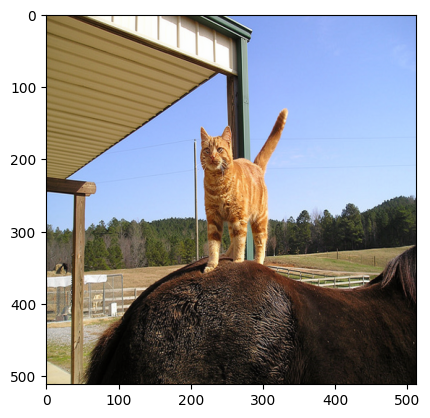

In [9]:
with torch.no_grad():
    latents = patchify_latents(latents)
    latents = latents * latents_bn_std
    latents = latents + latents_bn_mean
    latents = unpatchify_latents(latents)
    reconstructed = (vae.decode(latents).sample + 1.0 ) / 2.0

reconstructed = reconstructed.squeeze(0).permute((1, 2, 0)).cpu().numpy()
reconstructed = np.clip(reconstructed, 0, 1)

plt.imshow(reconstructed)
plt.show()

In [10]:
for _ in range(10):
    t = time.time()
    with torch.no_grad():
        image_norm = (img_tensor - 0.5) * 2
        latent = vae.encode(image_norm).latent_dist.mode()
        
    torch.cuda.synchronize()
    print("encode time", time.time() - t)

encode time 0.02460479736328125
encode time 0.02481245994567871
encode time 0.024578332901000977
encode time 0.023915767669677734
encode time 0.023825407028198242
encode time 0.023508548736572266
encode time 0.023644208908081055
encode time 0.023651838302612305
encode time 0.023767948150634766
encode time 0.024039030075073242
